# Test Analytic Deformation Fields

This notebook tests and visualizes the analytic displacement field generators:
- `generate_star`: Sinusoidal wave patterns
- `generate_curve`: Power-law gradients
- `generate_sphere`: Spherical tangential flow
- `generate_overall`: Composite field
- `generate_static`: Uniform displacement

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [3]:
from py_deffields.fields.analytic import (
    generate_star,
    generate_curve,
    generate_sphere,
    generate_overall,
    generate_static,
)

## Configuration

In [4]:
# Volume shape for testing
SHAPE = (64, 64, 64)
MAX_DISP = 16.0

# Random seed for reproducibility
SEED = 42

# Slice index for visualization (middle slice)
SLICE_IDX = SHAPE[2] // 2

## Helper Functions

In [5]:
def plot_displacement_slice(
    field: np.ndarray,
    slice_idx: int,
    title: str = "Displacement Field",
    figsize: tuple[int, int] = (14, 4),
) -> plt.Figure:
    """
    Plot a slice of a 3D displacement field showing all three components.
    
    Parameters
    ----------
    field : np.ndarray
        Displacement field of shape (D, H, W, 3).
    slice_idx : int
        Index along W axis to slice.
    title : str
        Title for the figure.
    figsize : tuple
        Figure size.
    
    Returns
    -------
    plt.Figure
        The matplotlib figure.
    """
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    fig.suptitle(f"{title} (slice w={slice_idx})", fontsize=12)
    
    # Extract slice
    slice_data = field[:, :, slice_idx, :]
    
    component_names = ['d (depth)', 'h (height)', 'w (width)']
    
    # Plot each component
    for i, (ax, name) in enumerate(zip(axes[:3], component_names)):
        data = slice_data[:, :, i].T  # Transpose for proper orientation
        vmax = np.abs(data).max()
        vmin = -vmax if vmax > 0 else -1
        
        im = ax.imshow(
            data,
            cmap='RdBu_r',
            origin='lower',
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(f'u_{name}')
        ax.set_xlabel('d')
        ax.set_ylabel('h')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Plot magnitude
    magnitude = np.linalg.norm(slice_data, axis=-1).T
    im = axes[3].imshow(
        magnitude,
        cmap='viridis',
        origin='lower',
    )
    axes[3].set_title('|u| (magnitude)')
    axes[3].set_xlabel('d')
    axes[3].set_ylabel('h')
    fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    return fig

In [6]:
def plot_quiver_slice(
    field: np.ndarray,
    slice_idx: int,
    subsample: int = 4,
    title: str = "Vector Field",
    figsize: tuple[int, int] = (6, 6),
) -> plt.Figure:
    """
    Plot a quiver (arrow) visualization of the displacement field slice.
    
    Shows the in-plane (d, h) components as arrows.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Extract slice and subsample
    slice_data = field[::subsample, ::subsample, slice_idx, :]
    
    # Create coordinate grid
    d_coords = np.arange(0, field.shape[0], subsample)
    h_coords = np.arange(0, field.shape[1], subsample)
    D, H = np.meshgrid(d_coords, h_coords, indexing='ij')
    
    # Get in-plane components
    U = slice_data[:, :, 0]  # d-component
    V = slice_data[:, :, 1]  # h-component
    
    # Color by magnitude
    magnitude = np.sqrt(U**2 + V**2)
    
    quiver = ax.quiver(
        D, H, U, V, magnitude,
        cmap='viridis',
        scale=None,
    )
    
    ax.set_title(f"{title} (slice w={slice_idx})")
    ax.set_xlabel('d')
    ax.set_ylabel('h')
    ax.set_aspect('equal')
    fig.colorbar(quiver, ax=ax, label='|u_dh|')
    
    plt.tight_layout()
    return fig

In [7]:
def print_field_stats(field: np.ndarray, name: str) -> None:
    """Print statistics about a displacement field."""
    print(f"\n{name}:")
    print(f"  Shape: {field.shape}")
    print(f"  dtype: {field.dtype}")
    print(f"  Range: [{field.min():.3f}, {field.max():.3f}]")
    print(f"  Mean:  {field.mean():.3f}")
    print(f"  Std:   {field.std():.3f}")
    mag = np.linalg.norm(field, axis=-1)
    print(f"  Max magnitude: {mag.max():.3f}")

## Generate All Field Types

In [8]:
# Create RNG for reproducibility
rng = np.random.default_rng(SEED)

# Generate all field types
fields = {}

fields['star'] = generate_star(
    shape=SHAPE,
    max_displacement=MAX_DISP,
    rng=np.random.default_rng(SEED),
)

fields['curve'] = generate_curve(
    shape=SHAPE,
    max_displacement=MAX_DISP,
    rng=np.random.default_rng(SEED),
)

fields['sphere'] = generate_sphere(
    shape=SHAPE,
    max_displacement=MAX_DISP,
    rng=np.random.default_rng(SEED),
)

fields['overall'] = generate_overall(
    shape=SHAPE,
    max_displacement=MAX_DISP,
    snr_db=30.0,
    rng=np.random.default_rng(SEED),
)

fields['static'] = generate_static(
    shape=SHAPE,
    max_displacement=MAX_DISP,
    rng=np.random.default_rng(SEED),
)

# Print stats for all fields
for name, field in fields.items():
    print_field_stats(field, name)


star:
  Shape: (64, 64, 64, 3)
  dtype: float64
  Range: [-15.298, 15.298]
  Mean:  -0.114
  Std:   10.536
  Max magnitude: 25.803

curve:
  Shape: (64, 64, 64, 3)
  dtype: float64
  Range: [-11.599, 10.236]
  Mean:  -0.149
  Std:   3.884
  Max magnitude: 14.208

sphere:
  Shape: (64, 64, 64, 3)
  dtype: float64
  Range: [-15.999, 16.000]
  Mean:  -0.486
  Std:   6.121
  Max magnitude: 19.930

overall:
  Shape: (64, 64, 64, 3)
  dtype: float64
  Range: [-12.671, 12.513]
  Mean:  0.340
  Std:   4.456
  Max magnitude: 17.775

static:
  Shape: (64, 64, 64, 3)
  dtype: float64
  Range: [-1.956, 11.475]
  Mean:  6.095
  Std:   5.799
  Max magnitude: 14.572


## 1. Star Field

Sinusoidal wave patterns with spatially varying periods.

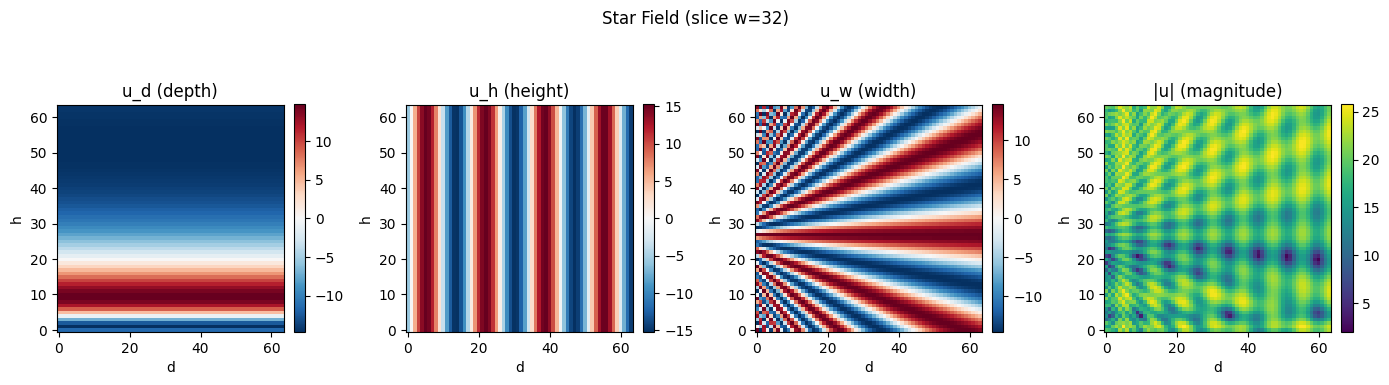

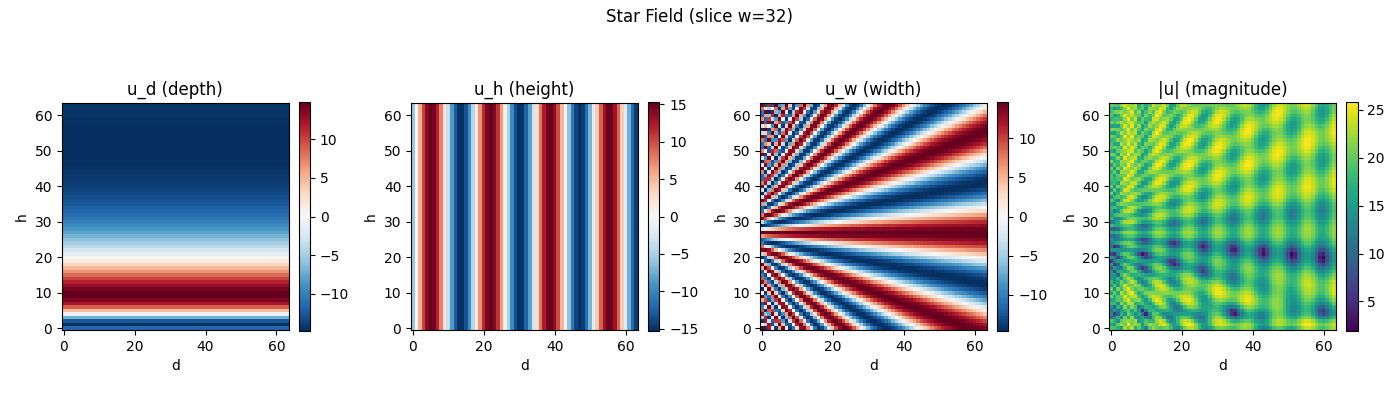

In [9]:
plot_displacement_slice(fields['star'], SLICE_IDX, title='Star Field')

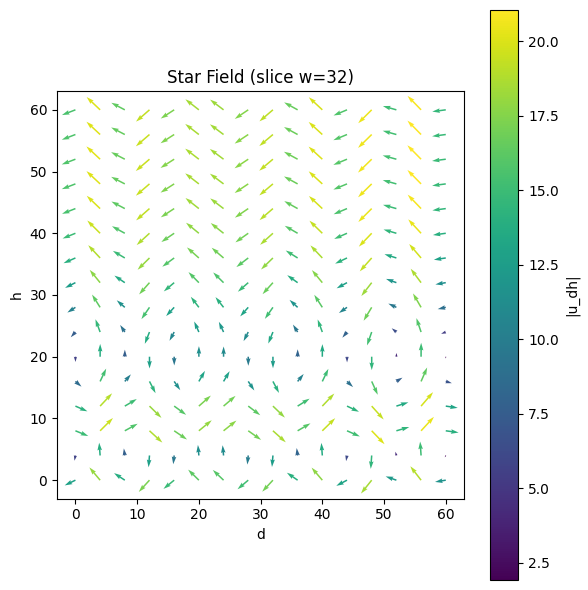

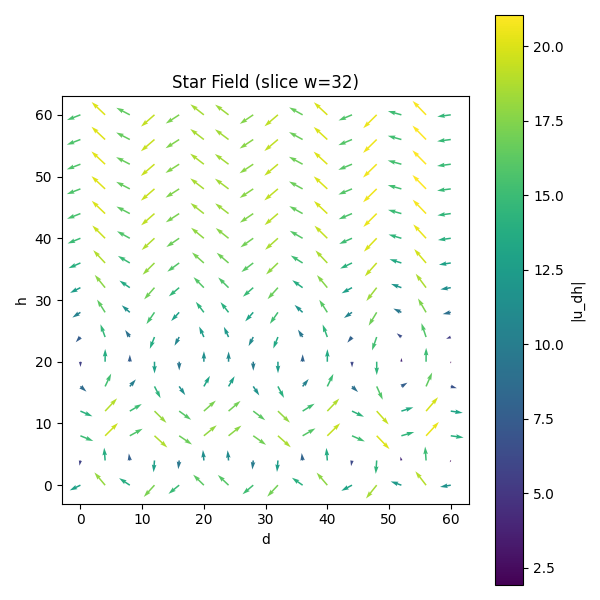

In [10]:
plot_quiver_slice(fields['star'], SLICE_IDX, title='Star Field')

## 2. Curve Field

Power-law gradients along each axis with rotation.

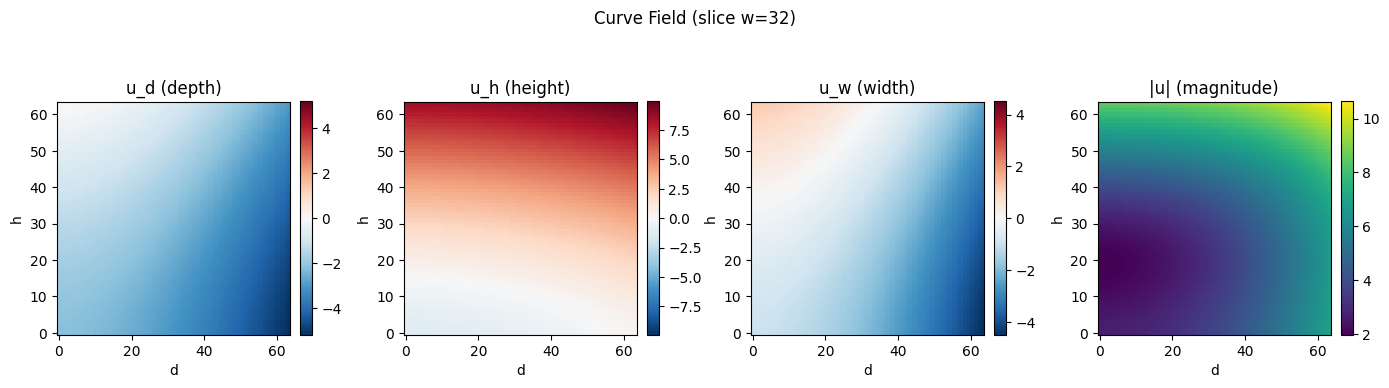

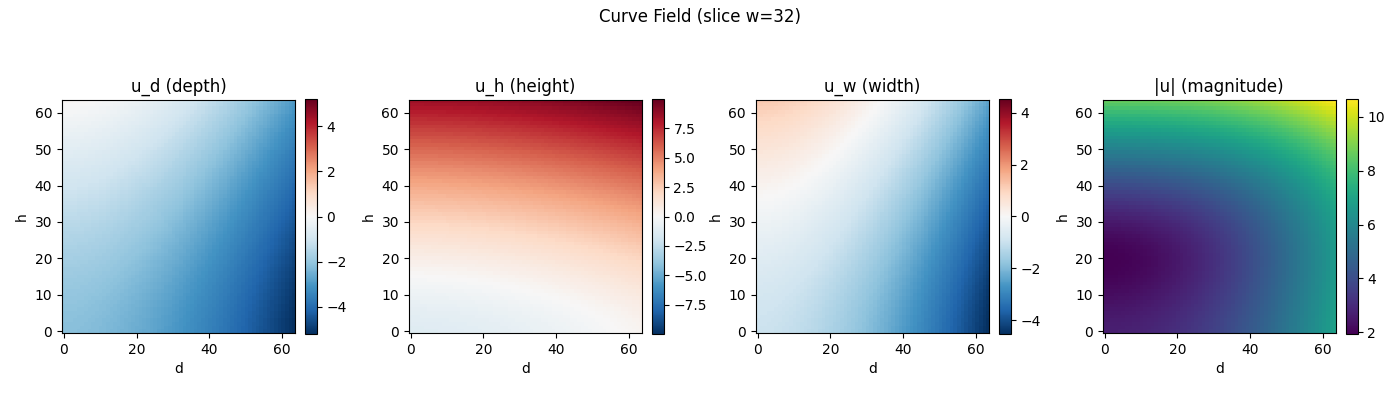

In [11]:
plot_displacement_slice(fields['curve'], SLICE_IDX, title='Curve Field')

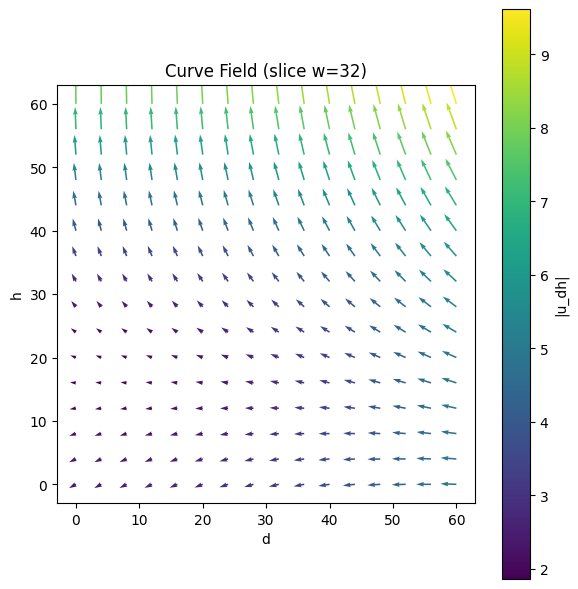

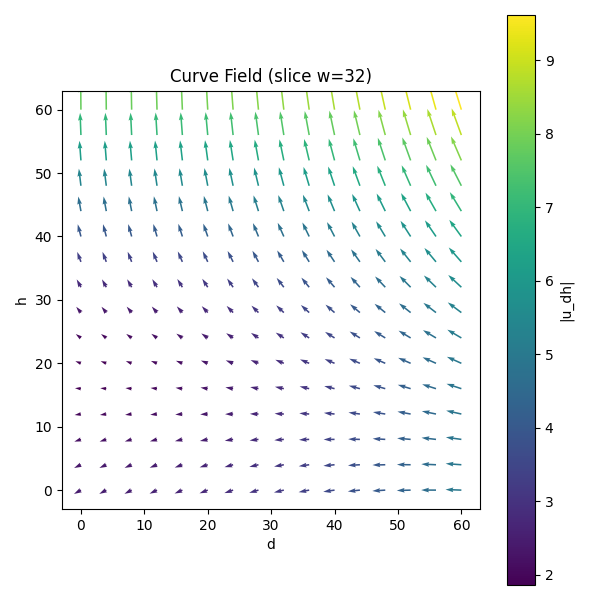

In [12]:
plot_quiver_slice(fields['curve'], SLICE_IDX, title='Curve Field')

## 3. Sphere Field

Spherical tangential flow (vortex patterns).

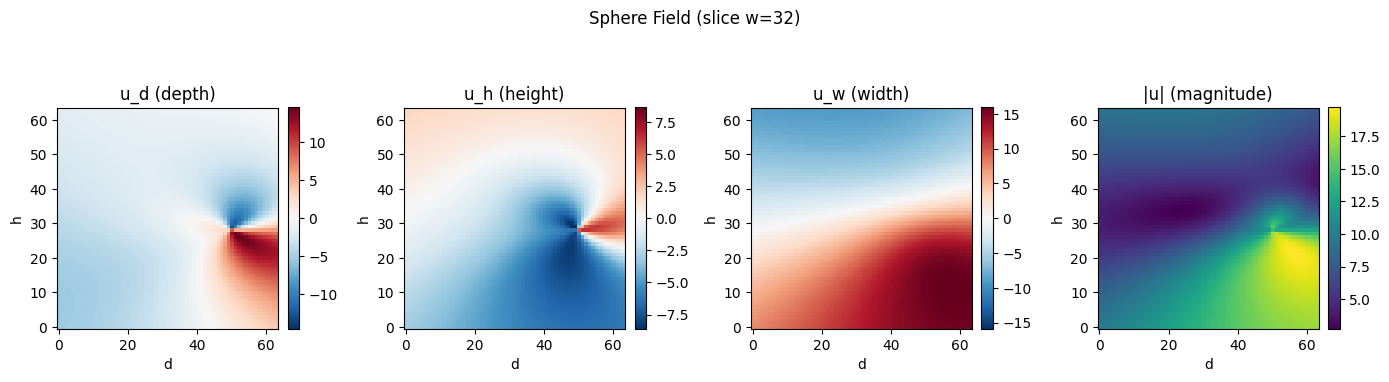

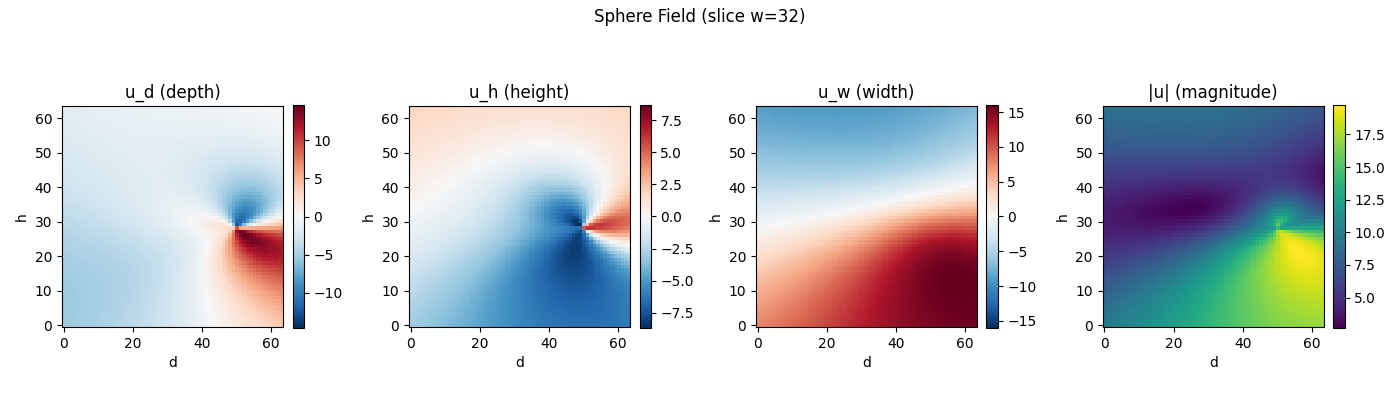

In [13]:
plot_displacement_slice(fields['sphere'], SLICE_IDX, title='Sphere Field')

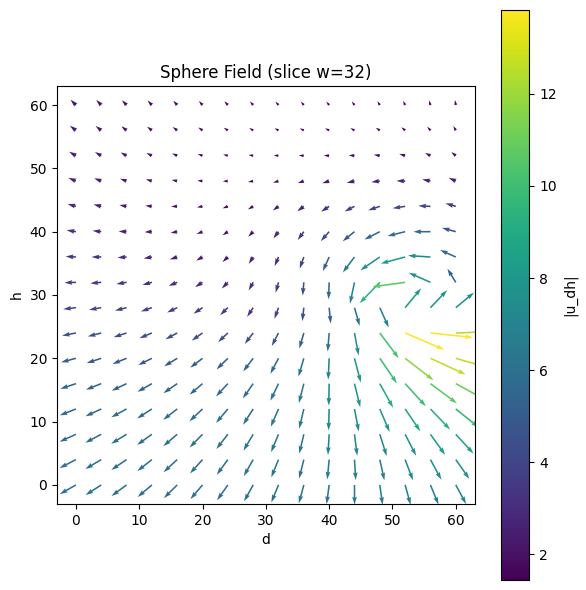

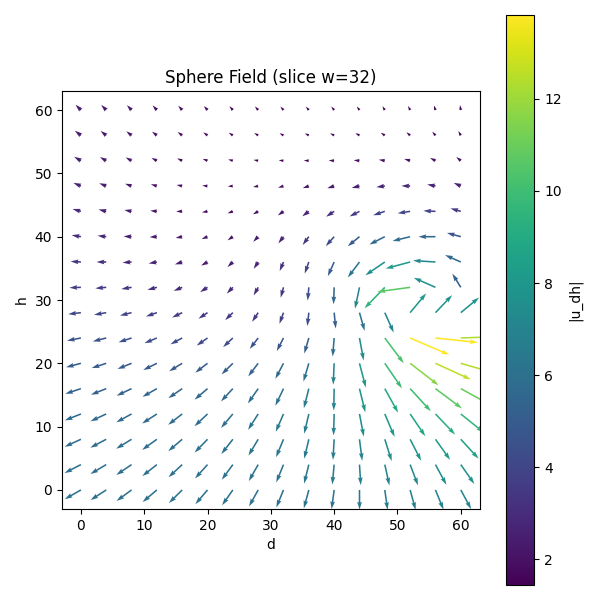

In [14]:
plot_quiver_slice(fields['sphere'], SLICE_IDX, title='Sphere Field')

## 4. Overall/Composite Field

Combination of sphere + star + polynomial modulation + noise.

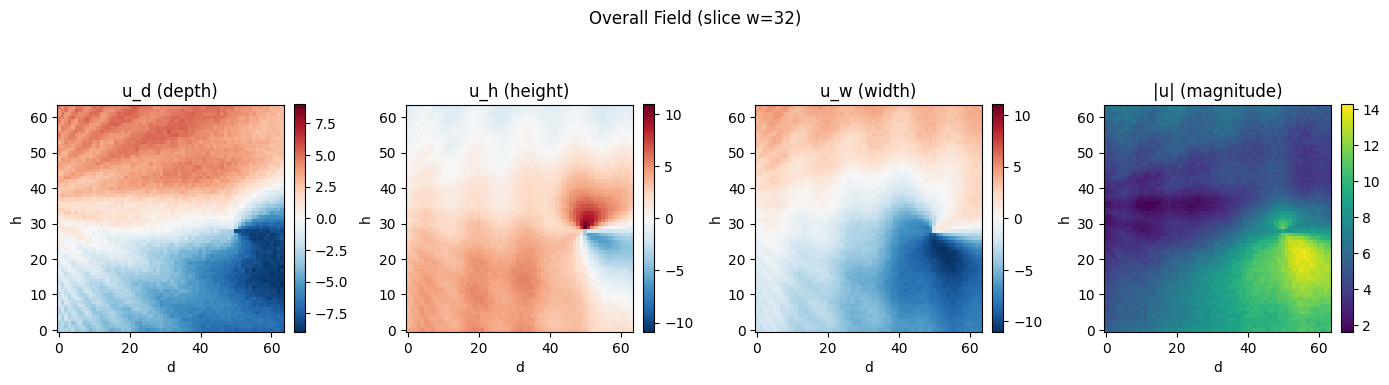

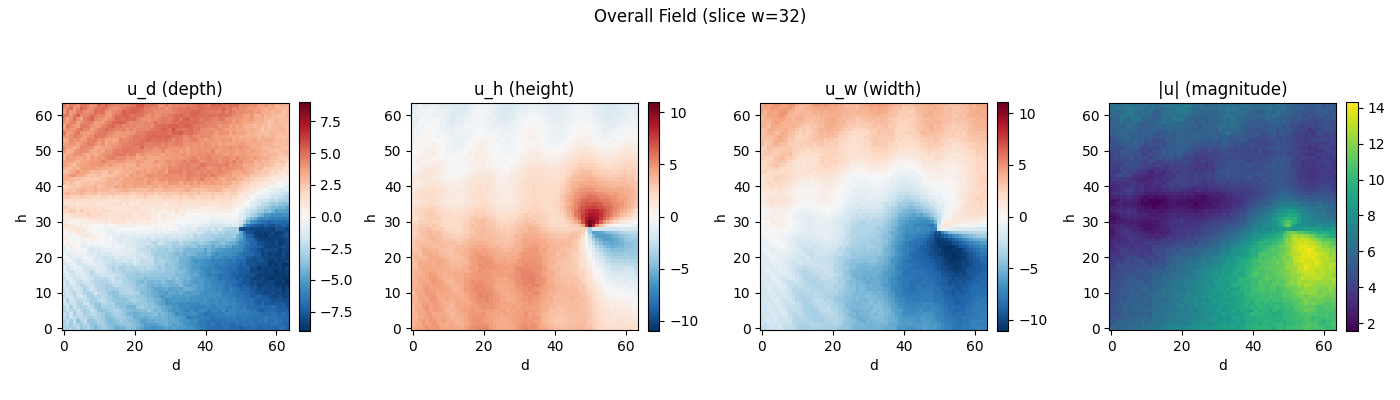

In [15]:
plot_displacement_slice(fields['overall'], SLICE_IDX, title='Overall Field')

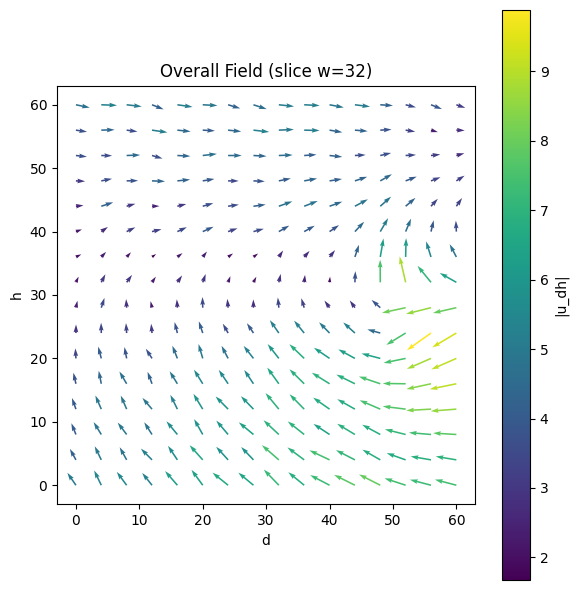

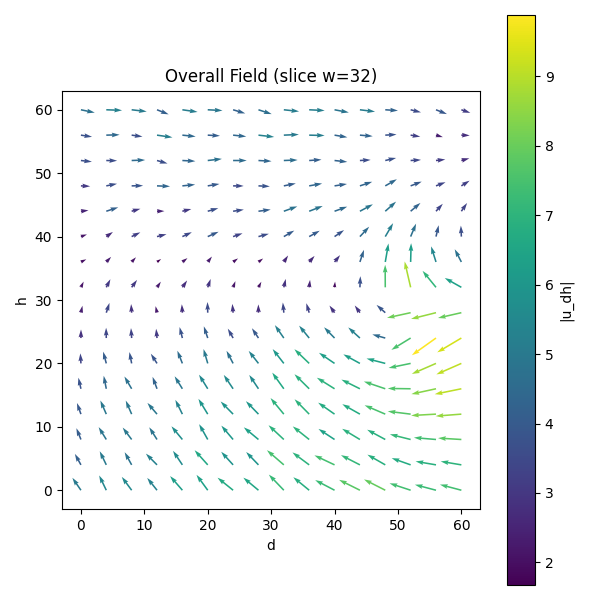

In [16]:
plot_quiver_slice(fields['overall'], SLICE_IDX, title='Overall Field')

## 5. Static Field

Uniform displacement (baseline/control).

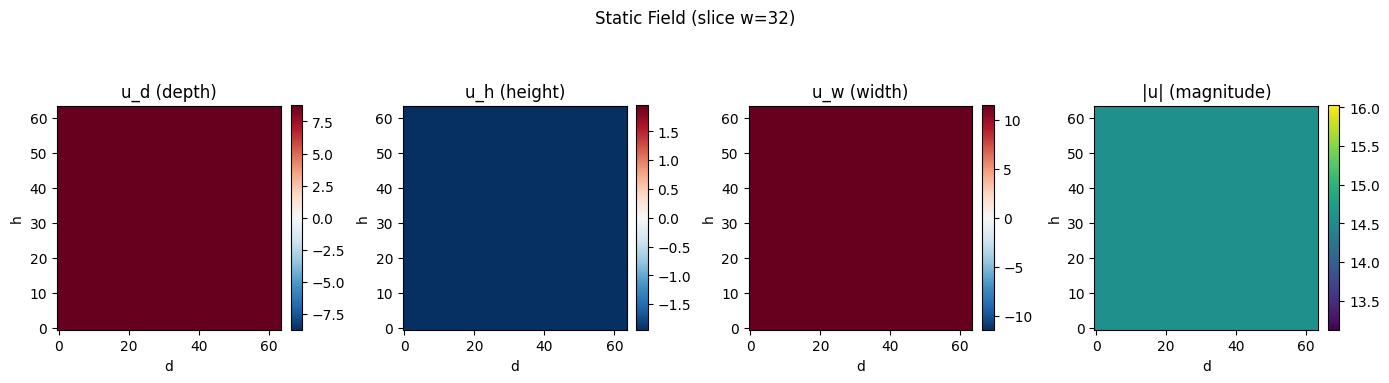

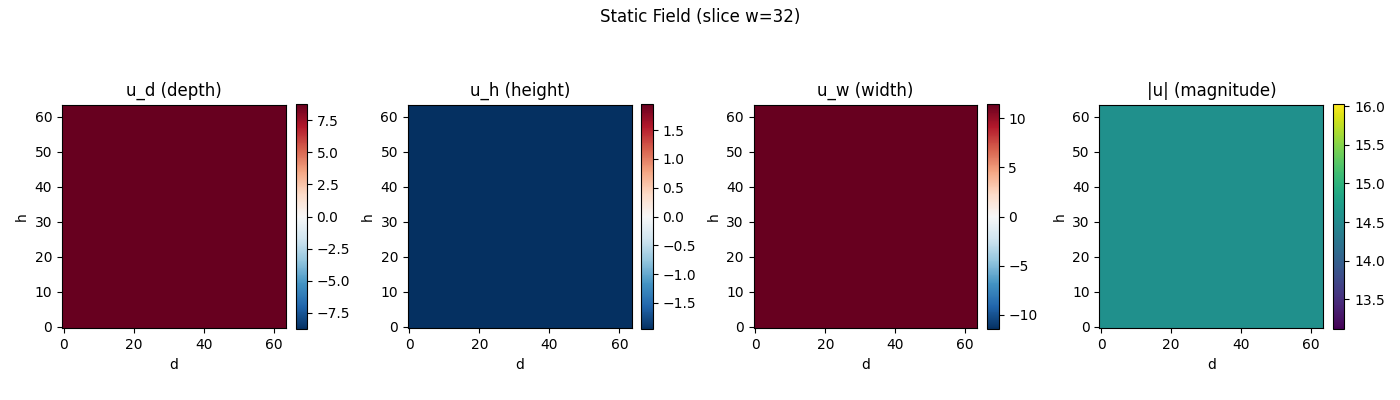

In [17]:
plot_displacement_slice(fields['static'], SLICE_IDX, title='Static Field')

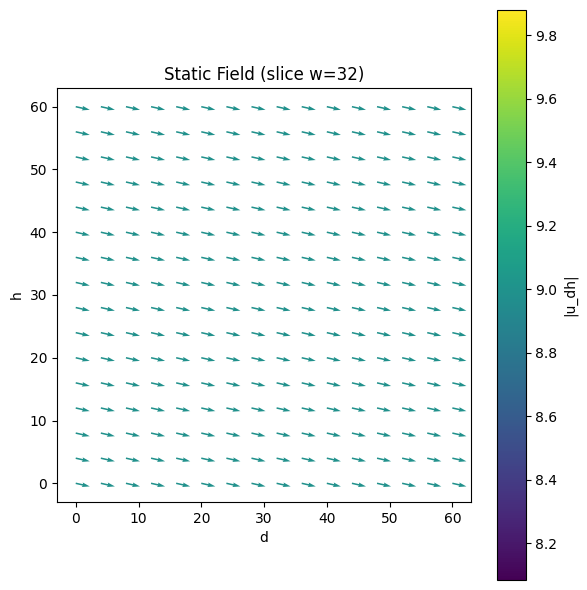

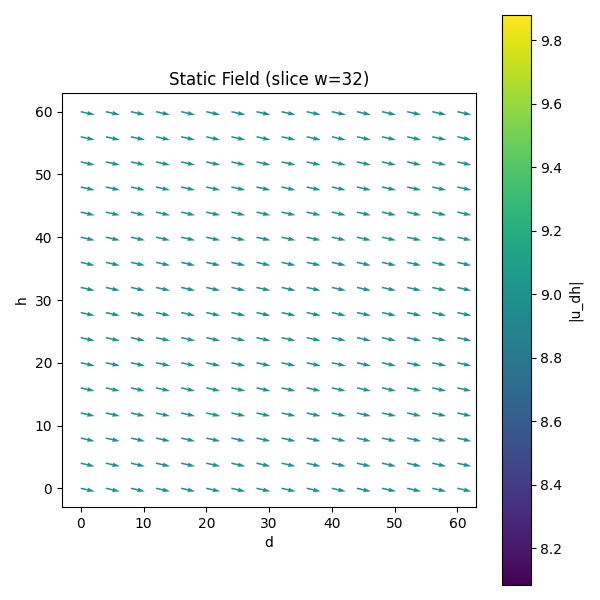

In [18]:
plot_quiver_slice(fields['static'], SLICE_IDX, title='Static Field')

## Comparison: All Fields Side-by-Side

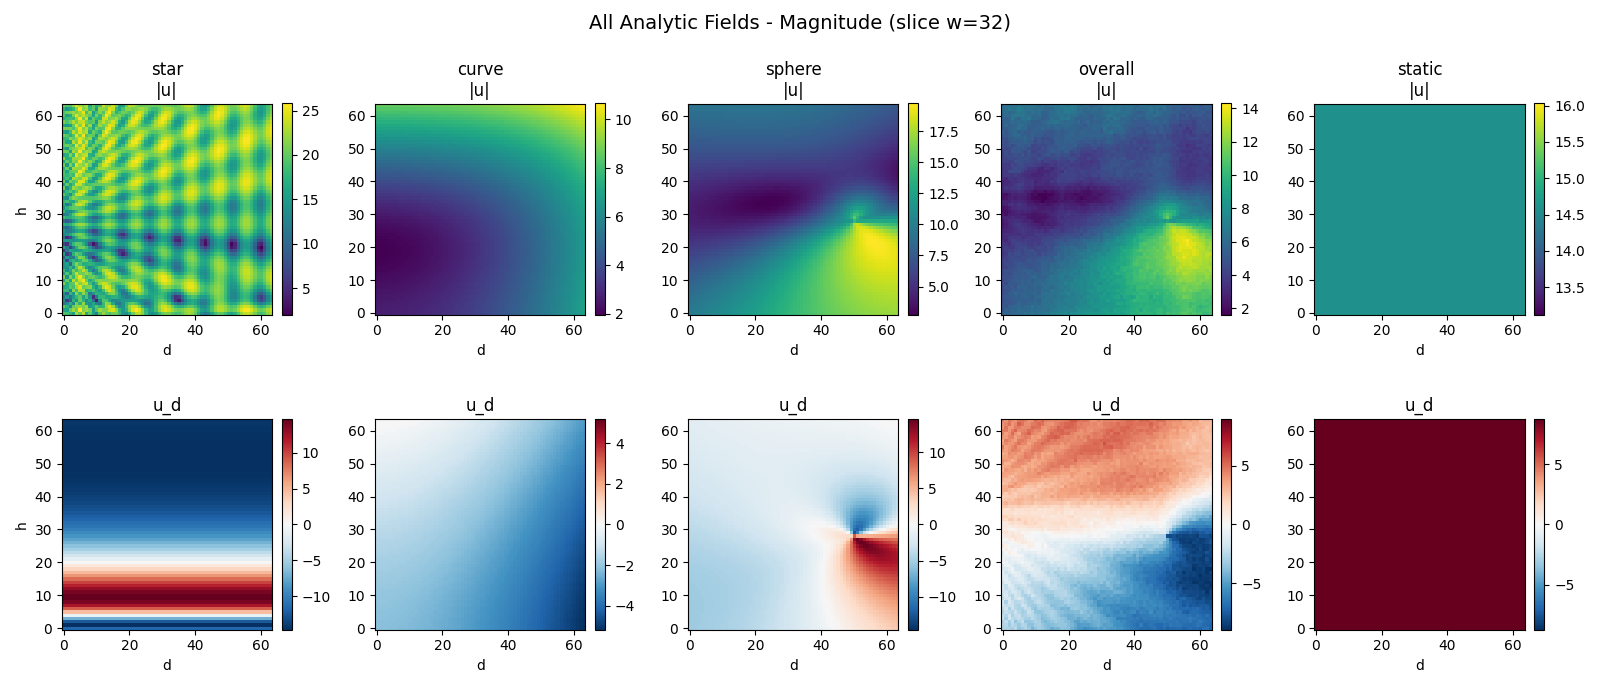

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle(f'All Analytic Fields - Magnitude (slice w={SLICE_IDX})', fontsize=14)

field_names = ['star', 'curve', 'sphere', 'overall', 'static']

for i, name in enumerate(field_names):
    field = fields[name]
    slice_data = field[:, :, SLICE_IDX, :]
    
    # Top row: magnitude
    magnitude = np.linalg.norm(slice_data, axis=-1).T
    im = axes[0, i].imshow(magnitude, cmap='viridis', origin='lower')
    axes[0, i].set_title(f'{name}\n|u|')
    axes[0, i].set_xlabel('d')
    if i == 0:
        axes[0, i].set_ylabel('h')
    fig.colorbar(im, ax=axes[0, i], fraction=0.046, pad=0.04)
    
    # Bottom row: d-component (depth displacement)
    d_comp = slice_data[:, :, 0].T
    vmax = np.abs(d_comp).max()
    im = axes[1, i].imshow(d_comp, cmap='RdBu_r', origin='lower', vmin=-vmax, vmax=vmax)
    axes[1, i].set_title(f'u_d')
    axes[1, i].set_xlabel('d')
    if i == 0:
        axes[1, i].set_ylabel('h')
    fig.colorbar(im, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.tight_layout()

## Interactive: Multiple Slices

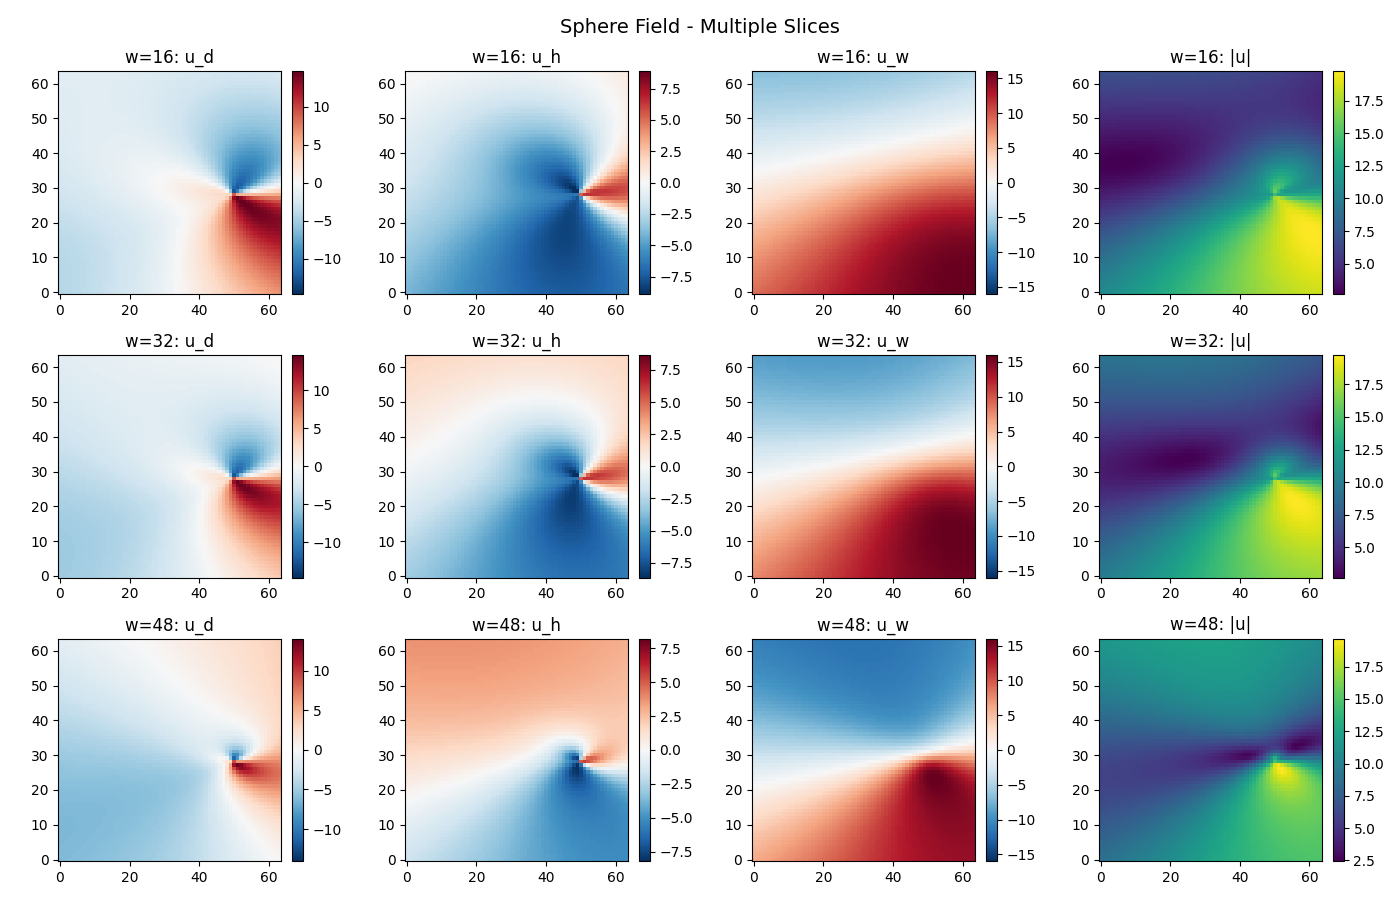

In [20]:
# Plot multiple slices for one field to see 3D structure
field_to_inspect = 'sphere'
slice_indices = [SHAPE[2] // 4, SHAPE[2] // 2, 3 * SHAPE[2] // 4]

fig, axes = plt.subplots(len(slice_indices), 4, figsize=(14, 3 * len(slice_indices)))
fig.suptitle(f'{field_to_inspect.title()} Field - Multiple Slices', fontsize=14)

for row, slice_idx in enumerate(slice_indices):
    slice_data = fields[field_to_inspect][:, :, slice_idx, :]
    component_names = ['u_d', 'u_h', 'u_w', '|u|']
    
    for col in range(3):
        data = slice_data[:, :, col].T
        vmax = np.abs(data).max()
        im = axes[row, col].imshow(data, cmap='RdBu_r', origin='lower', vmin=-vmax, vmax=vmax)
        axes[row, col].set_title(f'w={slice_idx}: {component_names[col]}')
        fig.colorbar(im, ax=axes[row, col], fraction=0.046, pad=0.04)
    
    # Magnitude
    magnitude = np.linalg.norm(slice_data, axis=-1).T
    im = axes[row, 3].imshow(magnitude, cmap='viridis', origin='lower')
    axes[row, 3].set_title(f'w={slice_idx}: {component_names[3]}')
    fig.colorbar(im, ax=axes[row, 3], fraction=0.046, pad=0.04)

plt.tight_layout()

## Parameter Exploration

TypeCheckError: Type-check error whilst checking the parameters of py_deffields.fields.analytic.generate_sphere.
The problem arose whilst typechecking parameter 'phase'.
Actual value: 0
Expected type: float | None.
----------------------
Called with parameters: {
  'shape': (64, 64, 64),
  'max_displacement': 16.0,
  'center': f64[3](numpy),
  'scale': f64[3](numpy),
  'velocity': None,
  'phase': 0,
  'rng': Generator(PCG64) at 0x7FE861F75C40
}
Parameter annotations: (shape: tuple[int, int, int], max_displacement: float = 16.0, center: Num[ndarray, '3'] | None = None, scale: Num[ndarray, '3'] | None = None, velocity: Num[ndarray, '3'] | None = None, phase: float | None = None, rng: numpy.random._generator.Generator | None = None) -> Any.


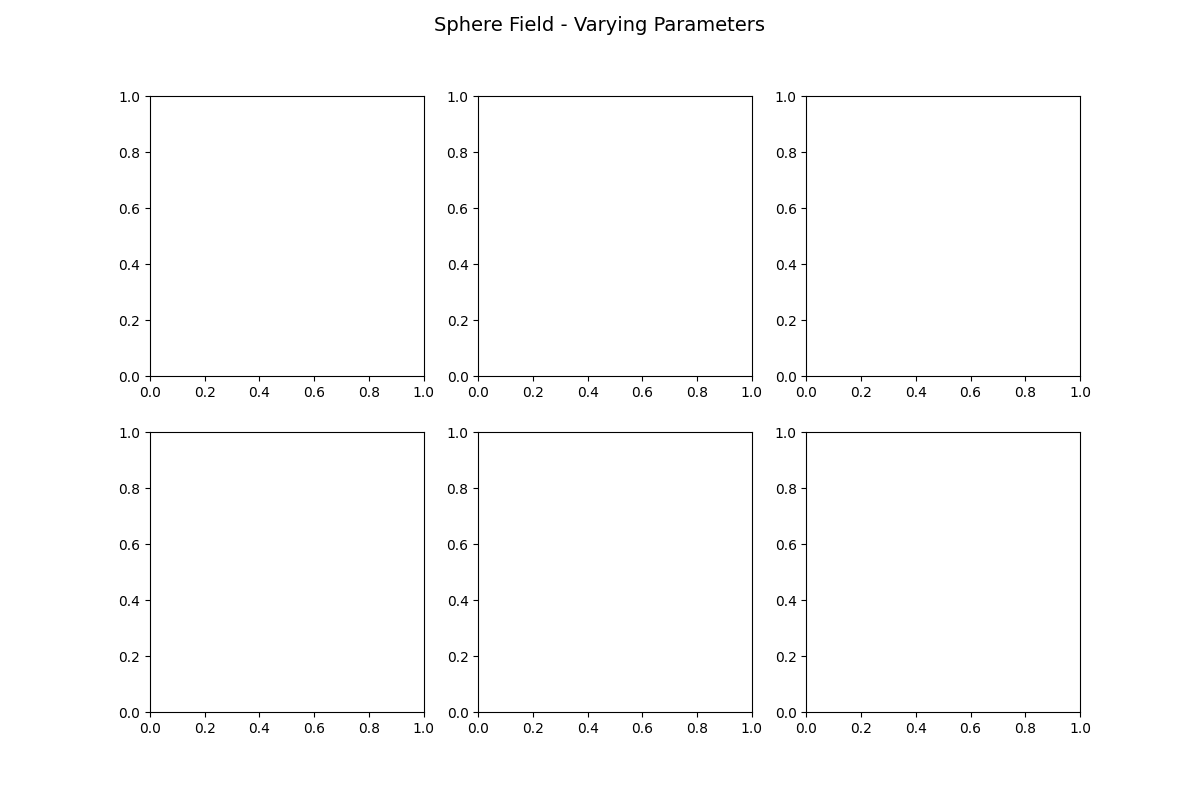

In [21]:
# Explore different parameters for sphere field
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Sphere Field - Varying Parameters', fontsize=14)

params_list = [
    {'center': np.array([0.5, 0.5, 0.5]), 'phase': 0},
    {'center': np.array([0.5, 0.5, 0.5]), 'phase': np.pi / 2},
    {'center': np.array([0.5, 0.5, 0.5]), 'phase': np.pi},
    {'center': np.array([0.3, 0.3, 0.5]), 'phase': 0},
    {'center': np.array([0.7, 0.7, 0.5]), 'phase': 0},
    {'center': np.array([0.5, 0.5, 0.5]), 'phase': 0, 'velocity': np.array([1.0, 0.0, 0.0])},
]

titles = [
    'center=(0.5,0.5,0.5), phase=0',
    'phase=π/2',
    'phase=π',
    'center=(0.3,0.3,0.5)',
    'center=(0.7,0.7,0.5)',
    'velocity=(1,0,0)',
]

for idx, (params, title) in enumerate(zip(params_list, titles)):
    row, col = idx // 3, idx % 3
    
    field = generate_sphere(
        shape=SHAPE,
        max_displacement=MAX_DISP,
        scale=np.array([1.0, 1.0, 1.0]),
        rng=np.random.default_rng(SEED),
        **params,
    )
    
    magnitude = np.linalg.norm(field[:, :, SLICE_IDX, :], axis=-1).T
    im = axes[row, col].imshow(magnitude, cmap='viridis', origin='lower')
    axes[row, col].set_title(title, fontsize=10)
    fig.colorbar(im, ax=axes[row, col], fraction=0.046, pad=0.04)

plt.tight_layout()

## Reproducibility Check

In [ ]:
# Verify reproducibility with same seed
field1 = generate_overall(shape=SHAPE, max_displacement=MAX_DISP, rng=np.random.default_rng(123))
field2 = generate_overall(shape=SHAPE, max_displacement=MAX_DISP, rng=np.random.default_rng(123))

print(f"Fields are identical: {np.allclose(field1, field2)}")
print(f"Max difference: {np.abs(field1 - field2).max()}")

Fields are identical: True
Max difference: 0.0
